# Recurrent Neural Networks: Forecasting the Weather

**Step 3: sequence models, illustrated with time series data**

So far our networks looked at each input — an image — in isolation. Many data are not like that: they arrive as **sequences**, where order carries information. Text is a sequence of words; a country's GDP is a sequence of quarterly figures; today's weather depends on yesterday's.

**Recurrent neural networks (RNNs)** are the canonical architecture for sequences. In natural language processing they have since been displaced by transformers (the "T" in GPT), but they remain a foundational idea every practitioner should have seen in action — and for modest-sized time series problems they are still a perfectly sensible tool.

Our task: using the past **5 days** of weather measurements, predict the temperature **24 hours ahead**.

### The data

The **Jena Climate dataset**: a weather station in Jena, Germany, recorded by the Max Planck Institute for Biogeochemistry. One measurement every **10 minutes** from 2009 to 2016 — about **420,000 observations** of 14 variables (temperature, pressure, humidity, wind, ...). Unlike the classic toy series (airline passengers: 144 points!), this is large enough for a neural network to earn its keep.

### Learning goals

1. Understand why **train/test splitting works differently for time series** — and what goes wrong if you shuffle.
2. Turn one long series into many supervised learning examples via **sliding windows**.
3. Explain the RNN idea: a **hidden state** carried through time, updated at every step with shared weights.
4. Always compare against a **naive baseline** — and see how hard such baselines can be to beat.
5. Recognize how the same machinery applies to language.

### Hardware

A GPU helps (Colab: **Runtime → Change runtime type → T4 GPU**) but this notebook is light enough that a CPU works too — training just takes a few minutes instead of seconds.


## 1. Setup

Nothing new here — the same imports as notebook 1, plus pandas for handling the raw data file.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cpu


## 2. Getting the data

The dataset is hosted as a zipped CSV at a stable Google URL; pandas can read it directly. (~13 MB download.)


In [2]:
url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
df = pd.read_csv(url)

df["Date Time"] = pd.to_datetime(df["Date Time"], format="%d.%m.%Y %H:%M:%S")
print(f"{len(df):,} rows, from {df['Date Time'].iloc[0]} to {df['Date Time'].iloc[-1]}")
df.head()


420,551 rows, from 2009-01-01 00:10:00 to 2017-01-01 00:00:00


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


### Subsampling to hourly resolution

Measurements every 10 minutes are more than we need — adjacent readings are nearly identical. We keep every 6th row, giving one observation per hour (~70,000 rows). This is a common and honest simplification; it also makes "predict 24 hours ahead" mean "predict 24 steps ahead."


In [3]:
df = df[5::6].reset_index(drop=True)   # every 6th row -> hourly
print(f"{len(df):,} hourly observations")


70,091 hourly observations


## 3. A first look — and a data-quality catch

Always plot a time series before modeling it. Two views:

- The **full eight years**: a strong *yearly* cycle (seasons).
- A **10-day zoom**: a clear *daily* cycle on top of it.

These regularities are what a model can exploit — and what makes the naive baseline we build later so competitive.


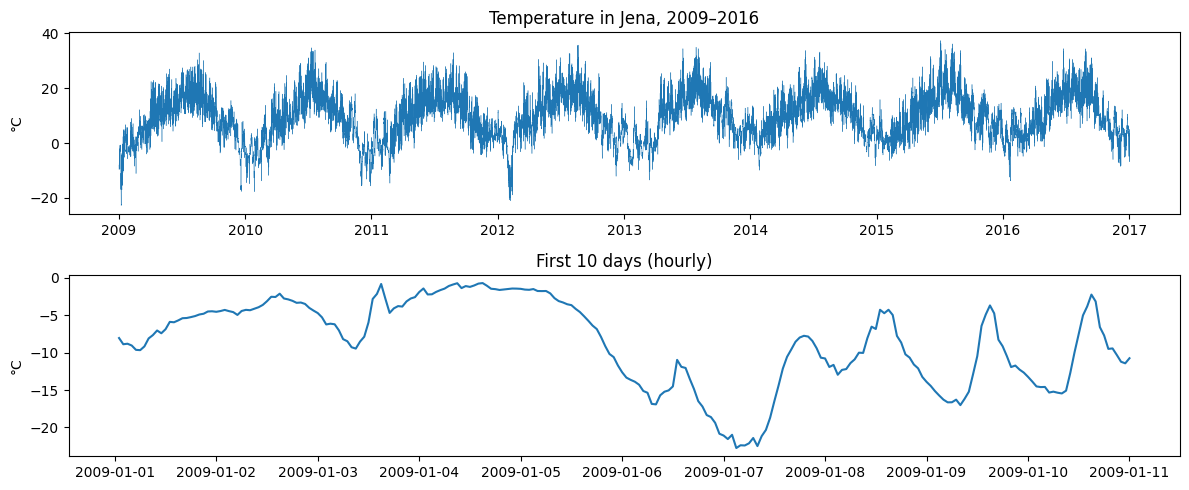

In [4]:
temp = df["T (degC)"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5))
ax1.plot(df["Date Time"], temp, linewidth=0.3)
ax1.set_title("Temperature in Jena, 2009–2016")
ax1.set_ylabel("°C")
ax2.plot(df["Date Time"][:240], temp[:240])
ax2.set_title("First 10 days (hourly)")
ax2.set_ylabel("°C")
plt.tight_layout()
plt.show()


Real data are messy. The wind-velocity columns use **-9999** as a missing-value code — if we fed that into a network it would dominate everything. A reminder that *looking at summary statistics is part of modeling*, in deep learning as much as in statistics.


In [5]:
print("Minimum of each column:")
print(df.min(numeric_only=True))

# Replace the -9999 sentinel values in the two wind columns with 0 (calm).
for col in ["wv (m/s)", "max. wv (m/s)"]:
    bad = df[col] == -9999.0
    print(f"\n{col}: replacing {bad.sum()} sentinel values")
    df.loc[bad, col] = 0.0


Minimum of each column:
p (mbar)            913.60
T (degC)            -22.76
Tpot (K)            250.85
Tdew (degC)         -24.80
rh (%)               13.88
VPmax (mbar)          0.97
VPact (mbar)          0.81
VPdef (mbar)          0.00
sh (g/kg)             0.51
H2OC (mmol/mol)       0.81
rho (g/m**3)       1059.45
wv (m/s)          -9999.00
max. wv (m/s)     -9999.00
wd (deg)              0.00
dtype: float64

wv (m/s): replacing 3 sentinel values

max. wv (m/s): replacing 4 sentinel values


## 4. Framing the problem: from one series to many examples

Supervised learning needs many (input, target) pairs — but we have *one* long series. The trick is the **sliding window**:

```
hours:      1 ......................... 120 | ... | 144
example 1:  [------- 120-hour input -------]        ^ target: temperature at hour 144
example 2:    [------- input (2..121) ------]         target: temperature at hour 145
example 3:      [------- input (3..122) -----]          target: hour 146
...
```

Every possible starting hour yields one training example: the **input** is a window of 120 consecutive hourly observations (each a vector of 14 measurements), and the **target** is the temperature 24 hours after the window ends. ~70,000 hours thus become ~70,000 overlapping examples — this is why a decently long series is "enough data" even though it is a single sequence.


In [6]:
WINDOW  = 120   # input: 5 days of hourly measurements
HORIZON = 24    # target: temperature 24 hours after the window ends

feature_cols = [c for c in df.columns if c != "Date Time"]
TEMP_IDX = feature_cols.index("T (degC)")

data = df[feature_cols].to_numpy(dtype="float32")
print(f"data array: {data.shape}  (hours, features)")


data array: (70091, 14)  (hours, features)


## 5. Splitting time series data — the part that is genuinely different

With MNIST we could split randomly: images are independent draws, so any subset is representative. **Time series break that logic in two ways.**

**First: the observations are not independent.** Consecutive hours are highly correlated, and our windowed examples *overlap* — example 2 shares 119 of its 120 input hours with example 1. If we shuffled all windows and split randomly, nearly every test window would have near-duplicates in the training set. The model could score brilliantly by memorization, and the test accuracy would be a **fiction**.

**Second: the point of forecasting is to predict the *future*.** A random split trains on 2015 data and "predicts" 2012 — a task that never occurs in reality. The honest simulation of deployment is: *train on the past, test on the future.*

So we split **chronologically**: first 70% of the timeline for training, next 15% for validation (model tuning), final 15% for testing (touched once, at the very end).

One subtlety worth internalizing: it *is* fine to shuffle the training windows **among themselves** during training (each window is a self-contained example, and shuffling helps optimization). The sin is letting windows from the test *period* — the future — influence training in any way.

### Normalization without leakage

That "no information from the future" rule extends to preprocessing: we standardize each variable using the mean and standard deviation **of the training period only**. Computing them on the full series would quietly leak facts about the future (e.g., its average temperature) into the model — a subtle but real form of **data leakage**, and one of the most common mistakes in applied forecasting.


In [7]:
n = len(data)
i_train, i_val = int(n * 0.70), int(n * 0.85)

train_arr = data[:i_train]
val_arr   = data[i_train:i_val]
test_arr  = data[i_val:]

# Standardize using TRAINING-period statistics only (no leakage from the future).
mean = train_arr.mean(axis=0)
std  = train_arr.std(axis=0)
train_arr = (train_arr - mean) / std
val_arr   = (val_arr   - mean) / std
test_arr  = (test_arr  - mean) / std

TEMP_STD = float(std[TEMP_IDX])   # to convert normalized errors back into °C

print(f"train: {len(train_arr):,} hours ({df['Date Time'].iloc[0].date()} … {df['Date Time'].iloc[i_train-1].date()})")
print(f"val:   {len(val_arr):,} hours ({df['Date Time'].iloc[i_train].date()} … {df['Date Time'].iloc[i_val-1].date()})")
print(f"test:  {len(test_arr):,} hours ({df['Date Time'].iloc[i_val].date()} … {df['Date Time'].iloc[-1].date()})")


train: 49,063 hours (2009-01-01 … 2014-08-05)
val:   10,514 hours (2014-08-05 … 2015-10-17)
test:  10,514 hours (2015-10-17 … 2016-12-31)


## 6. A `Dataset` class for windows

Remember the class detour in the CNN notebook? Here it pays off again. PyTorch lets us define a custom dataset by writing a class that inherits from `torch.utils.data.Dataset` and implements two methods:

- `__len__` — how many examples exist;
- `__getitem__` — build and return example number `i`.

Note what this buys us: we never materialize the ~70,000 windows in memory (each overlapping window would duplicate 120 rows of data — gigabytes in total). Instead, each window is **sliced out on demand** from the underlying array when the `DataLoader` asks for it. The `DataLoader` machinery — batching, shuffling — then works exactly as it did for MNIST.

Because we slice windows *within* each split, no window can straddle a split boundary — the chronological separation stays airtight.


In [8]:
class WindowDataset(Dataset):
    """Sliding windows over a (hours, features) array.

    Example i: input  = rows i .. i+WINDOW-1  (5 days of measurements),
               target = temperature at row i+WINDOW+HORIZON-1 (24 h after the window).
    """
    def __init__(self, arr, window=WINDOW, horizon=HORIZON):
        self.arr = arr
        self.window = window
        self.horizon = horizon

    def __len__(self):
        # Last valid start leaves room for the window plus the forecast horizon.
        return len(self.arr) - self.window - self.horizon + 1

    def __getitem__(self, i):
        x = torch.from_numpy(self.arr[i : i + self.window])            # (WINDOW, 14)
        y = torch.tensor(self.arr[i + self.window + self.horizon - 1, TEMP_IDX])
        return x, y

train_data = WindowDataset(train_arr)
val_data   = WindowDataset(val_arr)
test_data  = WindowDataset(test_arr)

# Shuffling training windows among themselves is fine (see section 5).
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=256, shuffle=False)

x, y = train_data[0]
print(f"{len(train_data):,} training windows; one input has shape {tuple(x.shape)}, target {y:.2f} (normalized °C)")


48,920 training windows; one input has shape (120, 14), target -3.49 (normalized °C)


## 7. Before any neural network: the naive baseline

Rule of forecasting (and of empirical work generally): **establish a dumb-but-honest baseline first.** Ours is *persistence*: predict that the temperature 24 hours from now equals the temperature right now. Because of the daily cycle, "same time yesterday" is a genuinely strong predictor.

We measure error as **MAE** (mean absolute error) in degrees Celsius — directly interpretable: "on average, off by X degrees."

Any model that cannot beat this number is worthless *no matter how sophisticated it is*. You would be surprised how much published forecasting work fails this test.


In [9]:
@torch.no_grad()
def persistence_mae(loader):
    """MAE (in °C) of predicting: temperature in 24h = temperature now."""
    abs_err, seen = 0.0, 0
    for x, y in loader:
        pred = x[:, -1, TEMP_IDX]          # last observed temperature in the window
        abs_err += (pred - y).abs().sum().item()
        seen += len(y)
    return abs_err / seen * TEMP_STD       # convert normalized error back to °C

baseline_val = persistence_mae(val_loader)
print(f"Persistence baseline, validation MAE: {baseline_val:.2f} °C")


Persistence baseline, validation MAE: 2.62 °C


## 8. What is a recurrent neural network?

A feed-forward network maps one fixed-size input to an output in a single shot. An RNN instead **reads a sequence step by step**, maintaining a **hidden state** `h` — a vector that acts as a running summary of everything seen so far:

```
h₀ = 0
h₁ = f(x₁, h₀)      read hour 1, update the summary
h₂ = f(x₂, h₁)      read hour 2, update the summary
...
h₁₂₀ = f(x₁₂₀, h₁₁₉) → final summary of all 5 days → predict from this
```

The update function `f` is a small neural network — and, crucially, it is the **same `f`, with the same weights, at every time step**. Compare this to the CNN from notebook 1: a convolution shares weights **across space** (one filter slides over the whole image); an RNN shares weights **across time** (one update rule slides along the sequence). Both are ways of building an assumption — spatial or temporal regularity — directly into the architecture, and both let the model handle inputs of any length.

Training works by "unrolling" the loop above into one long computational graph and applying ordinary backpropagation — called **backpropagation through time**.

### From RNN to LSTM

Vanilla RNNs have a famous flaw: as gradients flow backward through many steps of `f`, they tend to shrink toward zero (the **vanishing gradient problem**), so the network cannot learn dependencies more than a couple dozen steps long. The **LSTM** (Long Short-Term Memory, Hochreiter & Schmidhuber 1997) fixes this with learned **gates** that control what enters, stays in, and leaves the hidden state — creating a protected channel through which information (and gradients) can travel across long stretches of the sequence. The mechanics are intricate, but the interface is identical: sequence of vectors in, sequence of hidden states out. In practice one almost always uses an LSTM (or its lighter cousin, the GRU) rather than a vanilla RNN — as you will verify yourself in exercise 4.


## 9. The model

The same class pattern as notebook 1 — only the layers change:

- `nn.LSTM(input_size=14, hidden_size=64)` — the recurrent core. `batch_first=True` just says our tensors are laid out as `(batch, time, features)`. It processes the whole 120-step window and returns the hidden state at every step.
- We keep **only the final hidden state** `out[:, -1, :]` — the 64-dimensional summary of all 5 days — and feed it to a linear layer that outputs a single number: the predicted (normalized) temperature.

Note this is **regression**, not classification: one continuous output, no `.logits`, and an error-based loss instead of cross-entropy.


In [10]:
class LSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size,
                            num_layers=num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):                 # x: (batch, 120, 14)
        out, _ = self.lstm(x)             # out: (batch, 120, hidden) - hidden state at every step
        last = out[:, -1, :]              # keep the final summary: (batch, hidden)
        return self.head(last).squeeze(-1)  # (batch,) one predicted temperature each

model = LSTMForecaster(n_features=len(feature_cols)).to(device)
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


LSTMForecaster(
  (lstm): LSTM(14, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=1, bias=True)
)
Parameters: 20,545


## 10. Training — the loop you already know

Third notebook, same skeleton: forward → loss → backward → update. Only two details differ from the MNIST notebooks:

- The loss is **MAE** (`nn.L1Loss`) on the normalized temperature — so the loss itself, times `TEMP_STD`, *is* the error in °C. No separate accuracy metric needed.
- We monitor performance on the **validation** period after each epoch; the test period stays untouched until the end.


In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running, seen = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        loss = criterion(model(x), y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running += loss.item() * len(y)
        seen += len(y)
    return running / seen


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running, seen = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        running += criterion(model(x), y).item() * len(y)
        seen += len(y)
    return running / seen


criterion = nn.L1Loss()                     # mean absolute error
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 5
for epoch in range(1, EPOCHS + 1):
    tr = train_one_epoch(model, train_loader, criterion, optimizer, device)
    va = evaluate(model, val_loader, criterion, device)
    print(f"Epoch {epoch}: train MAE {tr * TEMP_STD:.2f} °C | val MAE {va * TEMP_STD:.2f} °C "
          f"(baseline: {baseline_val:.2f} °C)")


Epoch 1: train MAE 2.66 °C | val MAE 2.51 °C (baseline: 2.62 °C)
Epoch 2: train MAE 2.43 °C | val MAE 2.47 °C (baseline: 2.62 °C)
Epoch 3: train MAE 2.35 °C | val MAE 2.45 °C (baseline: 2.62 °C)
Epoch 4: train MAE 2.28 °C | val MAE 2.45 °C (baseline: 2.62 °C)
Epoch 5: train MAE 2.21 °C | val MAE 2.41 °C (baseline: 2.62 °C)


## 11. The verdict: model vs. baseline

Now — once — we consult the held-out test period, for both the LSTM and the persistence baseline.

Expect the LSTM to beat persistence, but **not by a landslide**. Sit with that for a moment: an 87,000-parameter network, five days of 14-variable history, backpropagation through time... and it improves on "same as now" by a modest margin. Weather has a large irreducibly stochastic component at a 24-hour horizon; strong seasonal and daily cycles mean the naive forecast already captures much of the predictable structure. This is the normal texture of real forecasting problems — and why baseline-free claims of predictive success should always raise an eyebrow.


In [12]:
test_mae = evaluate(model, test_loader, criterion, device) * TEMP_STD
baseline_test = persistence_mae(test_loader)

print(f"Test MAE — persistence baseline: {baseline_test:.2f} °C")
print(f"Test MAE — LSTM:                 {test_mae:.2f} °C")
print(f"Improvement: {100 * (baseline_test - test_mae) / baseline_test:.1f}%")


Test MAE — persistence baseline: 2.51 °C
Test MAE — LSTM:                 2.32 °C
Improvement: 7.4%


### Seeing the forecasts

Numbers are abstract; let's plot two weeks of the test period. Note the characteristic behavior of a forecaster under uncertainty: the predictions are a *smoothed* version of reality. The model hedges — extreme swings are irreducibly unpredictable 24 hours out, so the MAE-minimizing move is to stay close to the conditional center of the distribution.


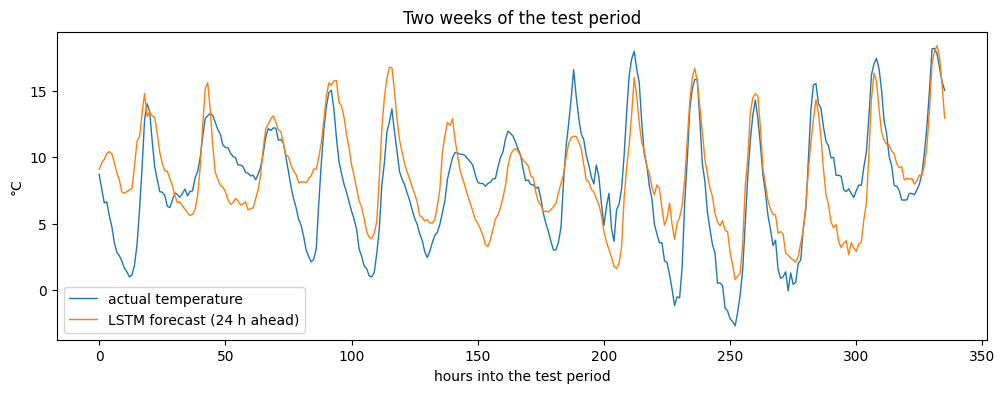

In [13]:
model.eval()
preds, actuals = [], []
with torch.no_grad():
    for x, y in test_loader:
        preds.append(model(x.to(device)).cpu())
        actuals.append(y)
        if sum(len(p) for p in preds) >= 336:   # two weeks of hourly forecasts
            break
preds = torch.cat(preds)[:336] * TEMP_STD + mean[TEMP_IDX]
actuals = torch.cat(actuals)[:336] * TEMP_STD + mean[TEMP_IDX]

plt.figure(figsize=(12, 4))
plt.plot(actuals, label="actual temperature", linewidth=1)
plt.plot(preds, label="LSTM forecast (24 h ahead)", linewidth=1)
plt.xlabel("hours into the test period")
plt.ylabel("°C")
plt.title("Two weeks of the test period")
plt.legend()
plt.show()


## 12. The bridge to language

Why is this architecture "canonical" for NLP? Replace the ingredients:

| Weather forecasting | Language modeling |
|---|---|
| one hour of measurements (vector of 14 numbers) | one word, as an **embedding** (vector of, say, 300 numbers) |
| window of 120 hours | a sentence or document |
| hidden state = summary of the last 5 days | hidden state = summary of the sentence so far |
| predict: temperature in 24 h | predict: the next word / the sentiment / the topic |

Structurally *nothing changes* — an RNN consumes a sequence of vectors and maintains a running summary, whether the vectors encode weather or words. For years, LSTMs were the state of the art across NLP (including the first versions of Google Translate's neural system).

Transformers displaced them for two main reasons. First, **parallelism**: an RNN must process step 2 after step 1 (each hidden state depends on the previous one), so long sequences cannot use modern hardware efficiently; a transformer's attention mechanism looks at all positions at once. Second, **long-range memory**: even an LSTM's summary vector is a bottleneck over thousands of words, while attention gives direct access to any earlier position. Neither limitation bites much at 120 time steps — which is why RNNs remain reasonable tools exactly here, on moderate-length time series.


## 13. Your turn

1. **Longer horizon.** Set `HORIZON = 72` (predict 3 days ahead) and rerun from section 6. What happens to the baseline, to the LSTM, and to the gap between them? Predict before you run.
2. **Less history.** Does the model really need 5 days? Try `WINDOW = 24`. What does the result tell you about where the predictive information lives?
3. **Univariate.** Keep only the temperature column as input (`n_features=1`; adapt the dataset). How much do the other 13 variables contribute?
4. **Vanilla RNN.** In `LSTMForecaster`, replace `nn.LSTM` with `nn.RNN` (a one-word change — the interface is identical). This is the vanishing-gradient problem of section 8 made visible: watch how training behaves over a 120-step sequence.
5. **Capacity.** Try `hidden_size=128` and/or `num_layers=2`. Worth it?
6. **Do it wrong — on purpose.** Build the windows over the *full* normalized series first and *then* split them randomly 70/15/15 (e.g., with `torch.utils.data.random_split`). Report the "test" MAE. It will look spectacular. Explain, in a sentence or two, why that number is a lie. *(This is the single most instructive exercise in the notebook — and the mistake this setup teaches you never to make.)*

## 14. Recap

- Time series require **chronological** train/validation/test splits — random splits let the future leak into training, via overlapping windows and even via normalization statistics.
- **Sliding windows** turn one long series into tens of thousands of supervised examples; a custom `Dataset` class serves them without copying data.
- An **RNN** shares one update rule across time (as a CNN shares filters across space), carrying a hidden-state summary; **LSTMs** add gates so that information and gradients survive long sequences.
- A **naive baseline** is non-negotiable, and beating it is harder than it looks.
- The same sequence machinery, fed word embeddings instead of weather vectors, was the workhorse of NLP before transformers — whose advantages (parallelism, direct long-range access) matter most at scales far beyond our 120 steps.

This completes the arc: **notebook 1** — build and understand an architecture from scratch; **notebook 2** — stand on the shoulders of pre-trained giants; **notebook 3** — respect the structure of your data, and the baselines that come with it.
